In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pl.read_csv('https://raw.githubusercontent.com/kirenz/datasets/refs/heads/master/gapminder.csv')

# Principios de visualización
- Datos usando pistas visuales
- Cuando utilizar el cero
- No distorsionar cantidades
- Ordenar categorías por valor
- Mostrar los datos
- Comparaciones fáciles
- Transformaciones
- Sesgo de las distribuiciones
- Ratios
- Pistas visuales deberían ser adyacentes
- Piensa en los daltónicos
- Gráficas para dos sub gráficas
- Incluir una tercerca variable
- Evitar gráficas pseudo-3d
- Evitar demasiados digitos
- Conocer a tu audiencia

In [3]:

df_2007 = df.filter(pl.col('year') == 2007)
df_1952 = df.filter(pl.col('year') == 1952)

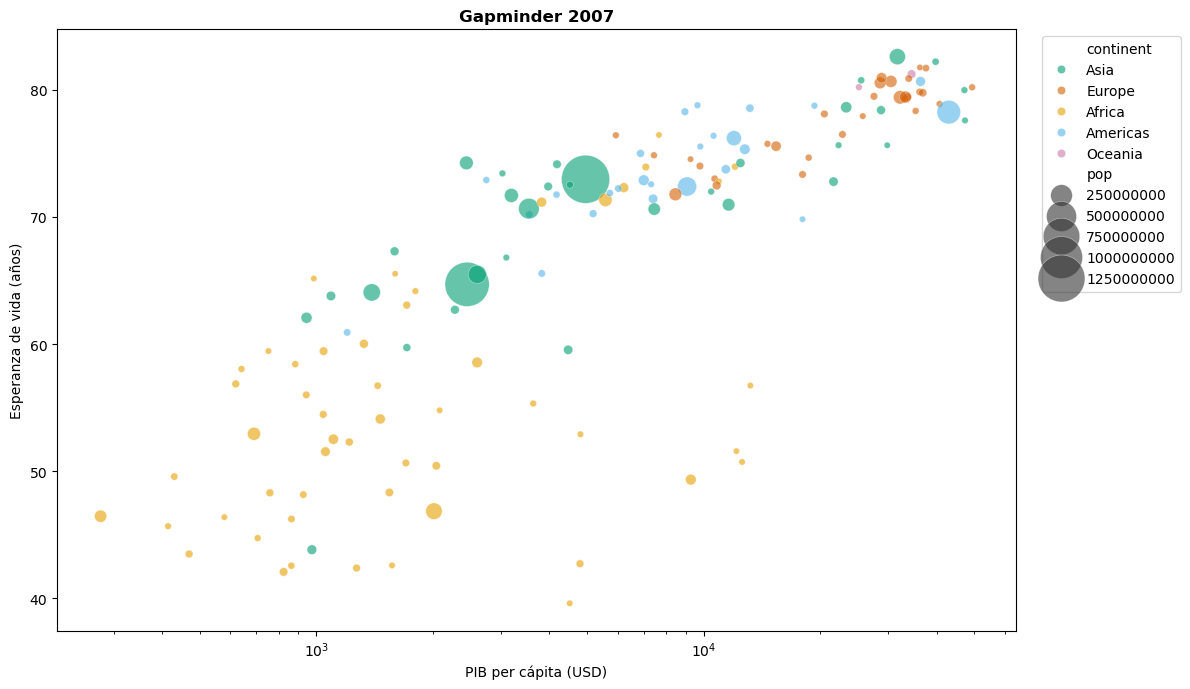

In [4]:
colores = {
    'Africa': '#E69F00', 
    'Americas': '#56B4E9', 
    'Asia': '#009E73', 
    'Europe': '#D55E00', 
    'Oceania': '#CC79A7'
}

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_2007.to_pandas(),
    x='gdpPercap',
    y='lifeExp',
    hue='continent',
    size='pop',
    sizes=(20, 1200),
    palette=colores,
    alpha=0.6
)

plt.xscale('log')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Esperanza de vida (años)')
plt.title('Gapminder 2007', fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
from pathlib import Path
from PIL import Image
IMG_DIR = Path('img')
def show_image(name, title=None, figsize=(10, 6)):
    """Muestra una imagen descargada."""
    for ext in ['.png', '.jpg']:
        path = IMG_DIR / f"{name}{ext}"
        if path.exists():
            img = Image.open(path)
            plt.figure(figsize=figsize)
            plt.imshow(img)
            plt.axis('off')
            if title:
                plt.title(title, fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()
            return
    print(f"Imagen '{name}' no encontrada")


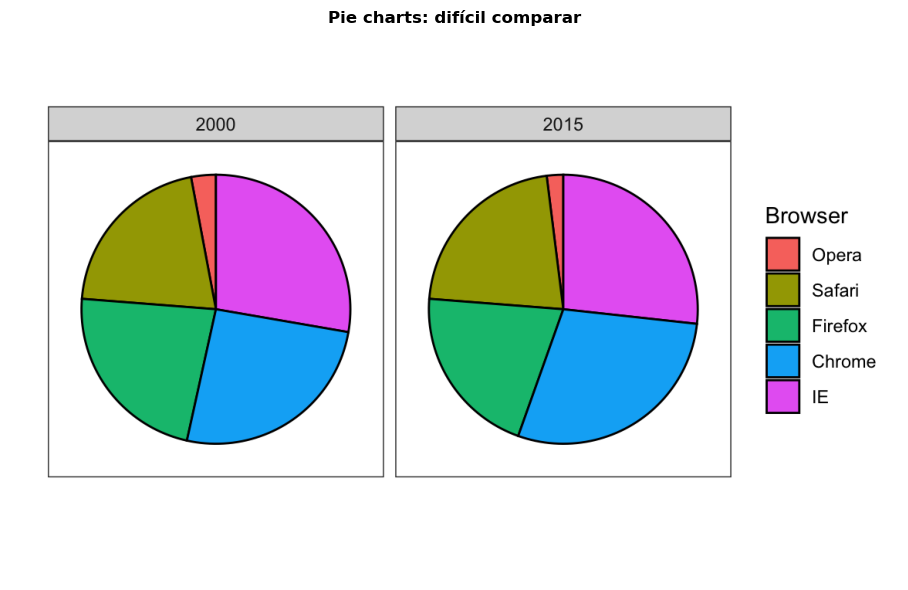

In [11]:
show_image('piechart', 'Pie charts: difícil comparar')

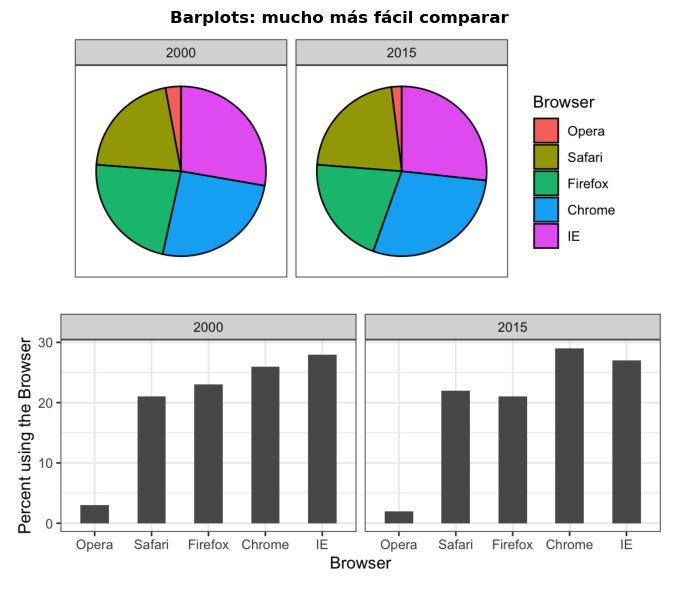

In [12]:
show_image('two_barplots', 'Barplots: mucho más fácil comparar')

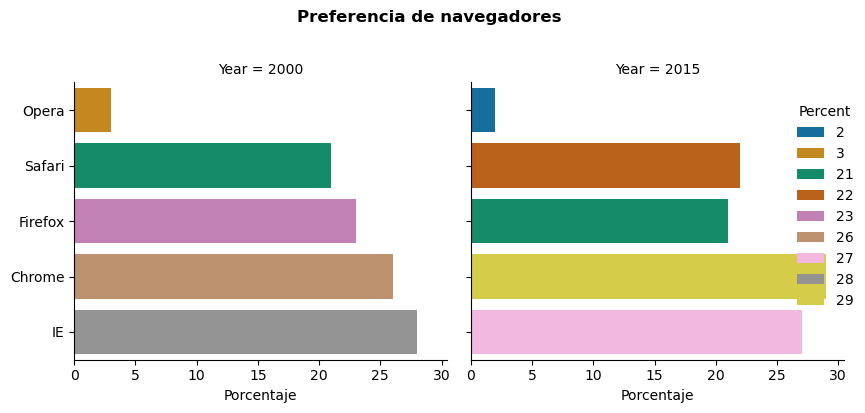

In [15]:
# Recrear con Seaborn
browsers = pl.DataFrame({
    'Browser': ['Opera', 'Safari', 'Firefox', 'Chrome', 'IE'] * 2,
    'Year': ['2000'] * 5 + ['2015'] * 5,
    'Percent': [3, 21, 23, 26, 28, 2, 22, 21, 29, 27]
})

g = sns.catplot(
    data=browsers.to_pandas(),
    x='Percent', y='Browser',
    col='Year',
    kind='bar',
    hue='Percent',
    palette='colorblind',
    height=4, aspect=1
)
g.set_axis_labels('Porcentaje', '')
g.figure.suptitle('Preferencia de navegadores', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

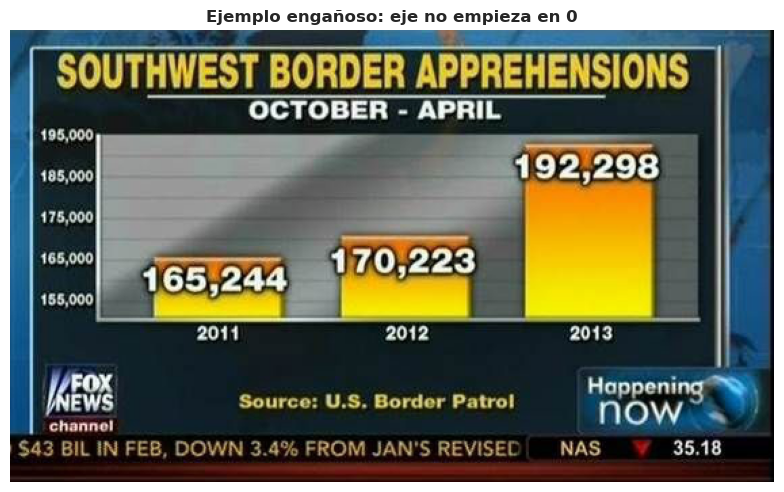

In [12]:
show_image('fox_news_1', 'Ejemplo engañoso: eje no empieza en 0', figsize=(8, 5))

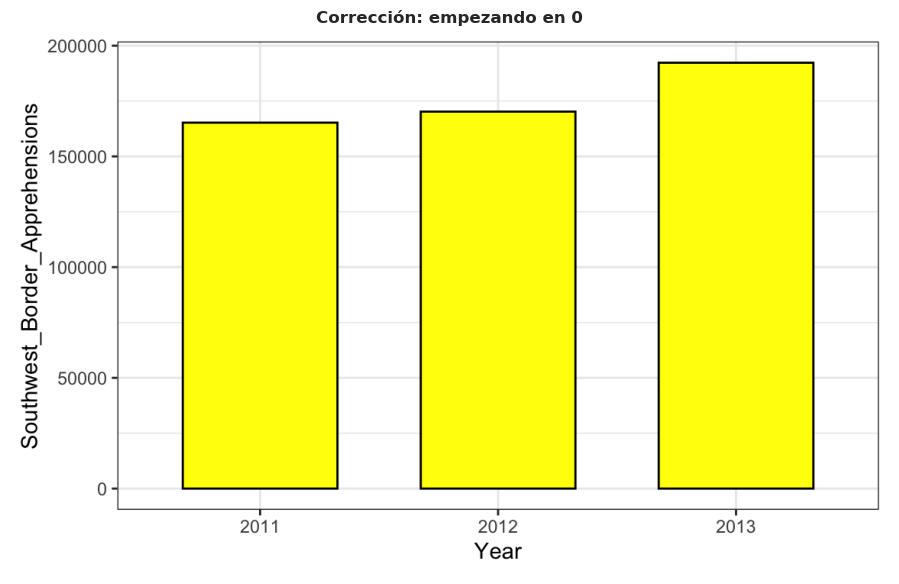

In [13]:
show_image('barplot_from_zero_1', 'Corrección: empezando en 0')

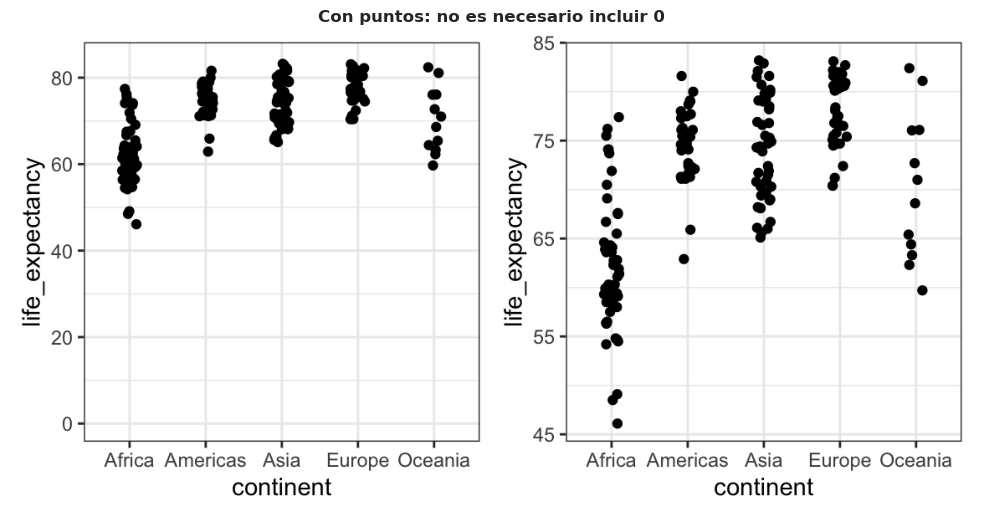

In [14]:
show_image('points_not_from_zero', 'Con puntos: no es necesario incluir 0')

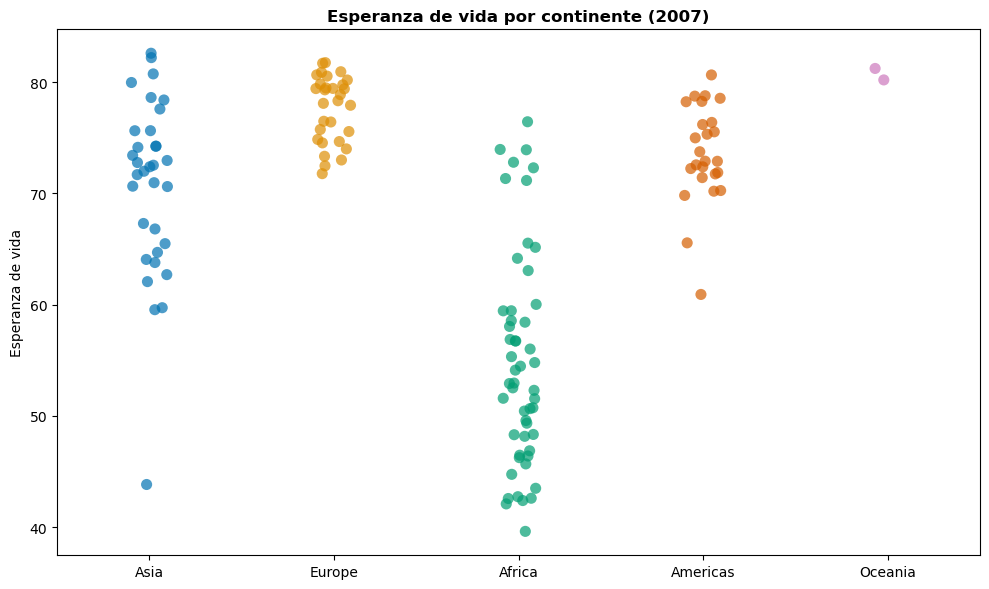

In [17]:
# Recrear: esperanza de vida por continente
plt.figure(figsize=(10, 6))

sns.stripplot(
    data=df_2007.to_pandas(), 
    x='continent', 
    y='lifeExp',
    hue='continent',
    palette='colorblind', 
    alpha=0.7,
    size=8
)

plt.xlabel('')
plt.ylabel('Esperanza de vida')
plt.title('Esperanza de vida por continente (2007)', fontweight='bold')
plt.tight_layout()
plt.show()

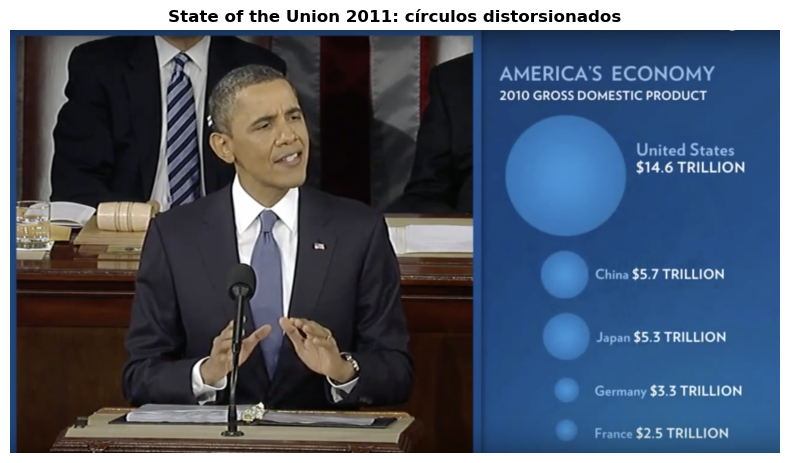

In [18]:
show_image('state_of_union', 'State of the Union 2011: círculos distorsionados', figsize=(8, 6))

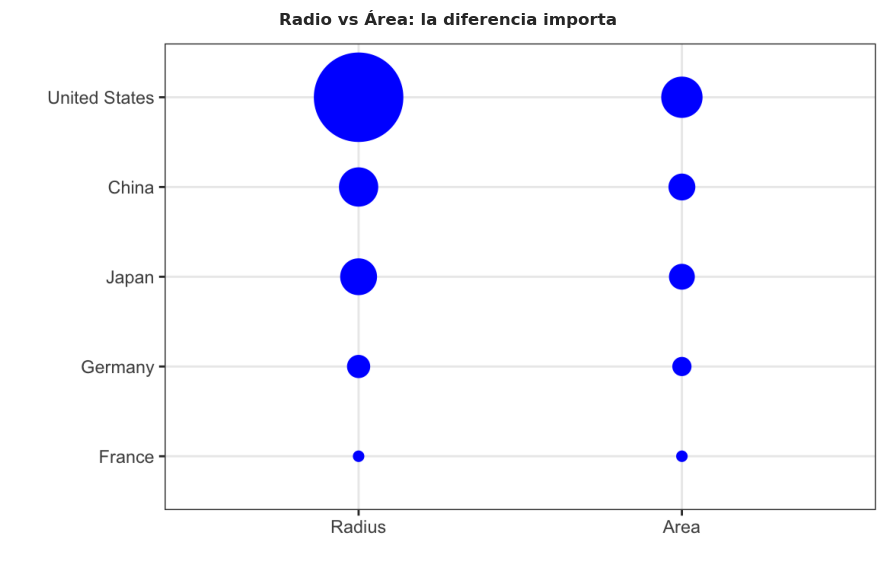

In [18]:
show_image('area_not_radius', 'Radio vs Área: la diferencia importa')

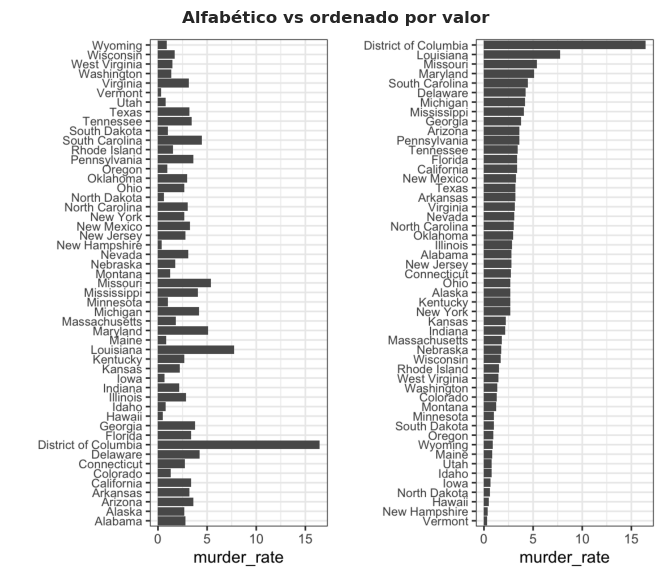

In [19]:
show_image('order_alphabetically', 'Alfabético vs ordenado por valor')

<Axes: xlabel='lifeExp', ylabel='country'>

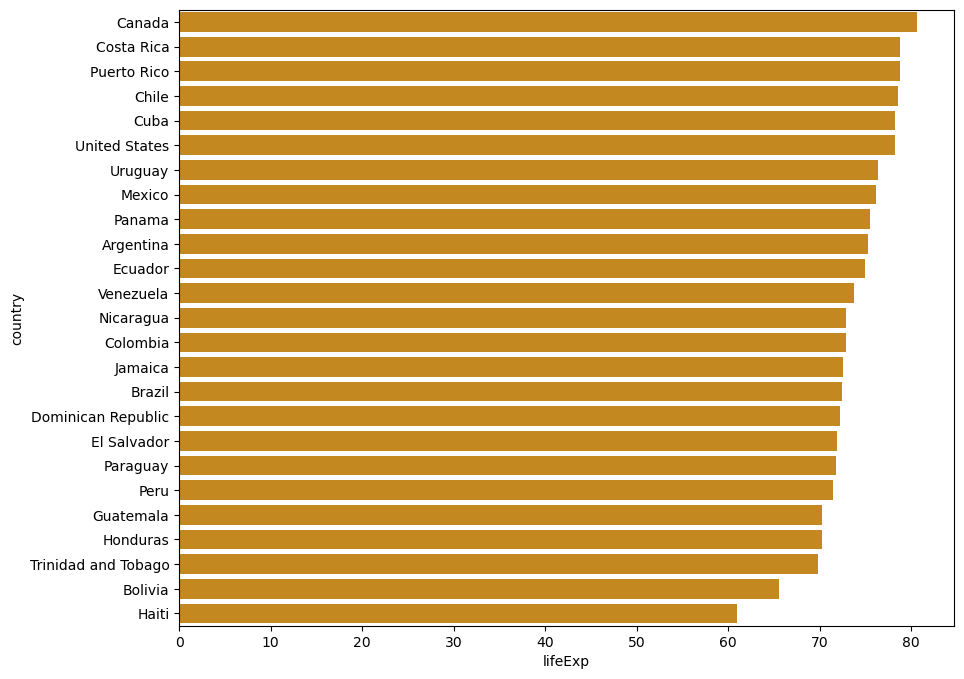

In [20]:
# Recrear: países de América ordenados por esperanza de vida
COLORBLIND_PALETTE=sns.color_palette("colorblind")
americas = df_2007.filter(pl.col('continent') == 'Americas')
order = americas.sort('lifeExp', descending=True)['country'].to_list()

plt.figure(figsize=(10, 8))

sns.barplot(
    data=americas.to_pandas(), 
    y='country', 
    x='lifeExp',
    order=order,
    color=COLORBLIND_PALETTE[1]  # Un solo color en lugar de paleta
)

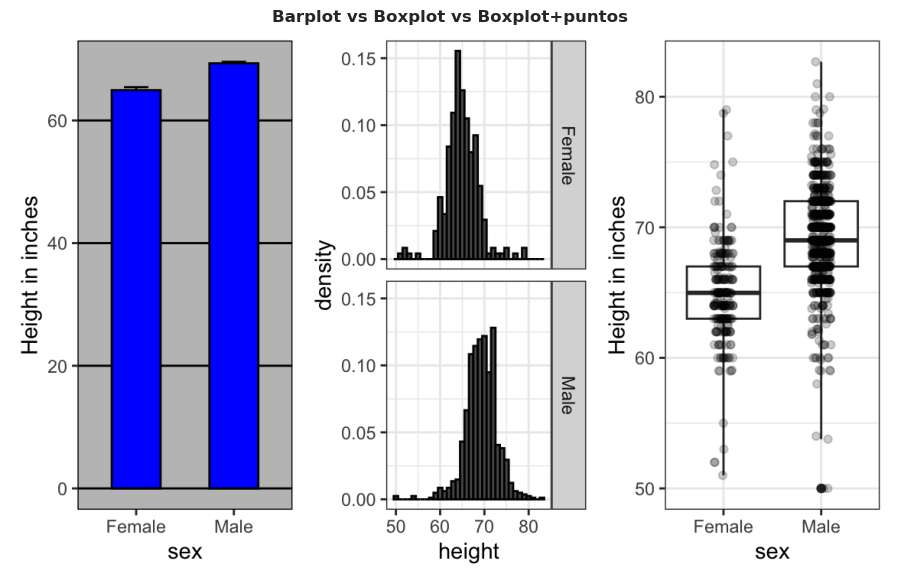

In [23]:
show_image('show_data_comparison', 'Barplot vs Boxplot vs Boxplot+puntos')

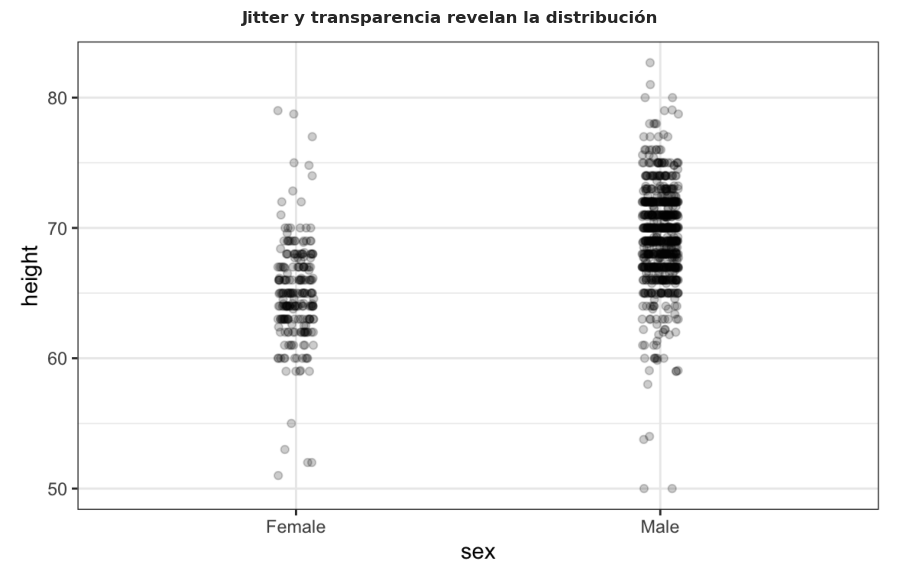

In [24]:
show_image('jitter', 'Jitter y transparencia revelan la distribución')

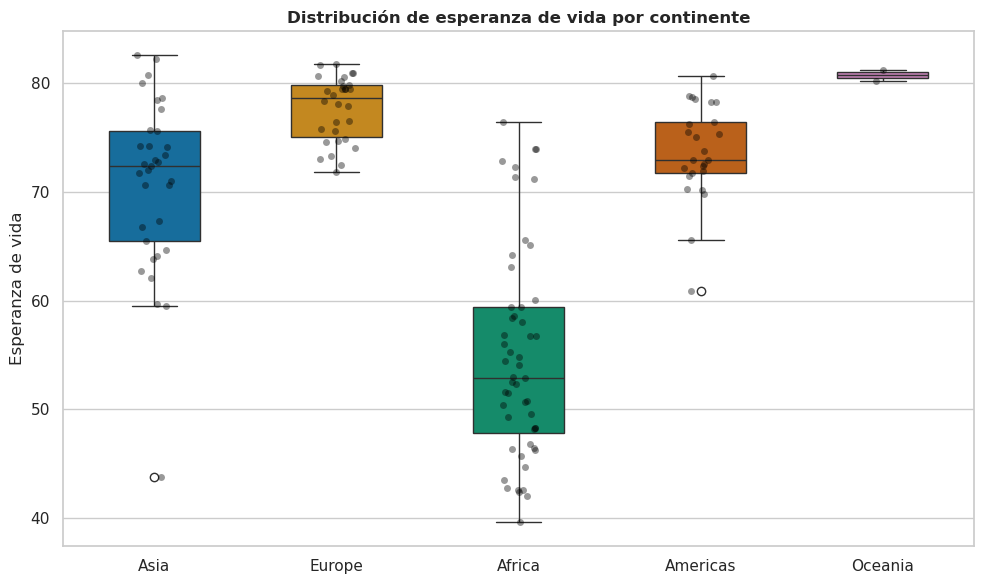

In [28]:
# Recrear: boxplot con puntos
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_2007.to_pandas(), 
    x='continent', 
    y='lifeExp',
    hue='continent',        # Asignar hue a la misma variable
    #order=order,
    #hue_order=order,
    palette='colorblind',
    legend=False,
    width=0.5
)
sns.stripplot(
    data=df_2007.to_pandas(), 
    x='continent', 
    y='lifeExp',
    color='black', 
    alpha=0.4, 
    size=5
)

plt.xlabel('')
plt.ylabel('Esperanza de vida')
plt.title('Distribución de esperanza de vida por continente', fontweight='bold')
plt.tight_layout()
plt.show()

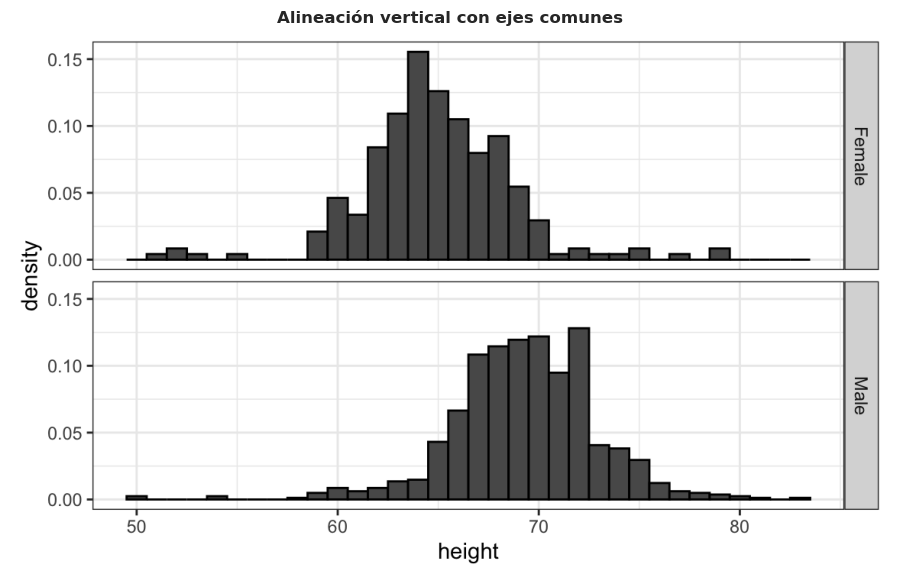

In [29]:
show_image('histograms_vertical', 'Alineación vertical con ejes comunes')

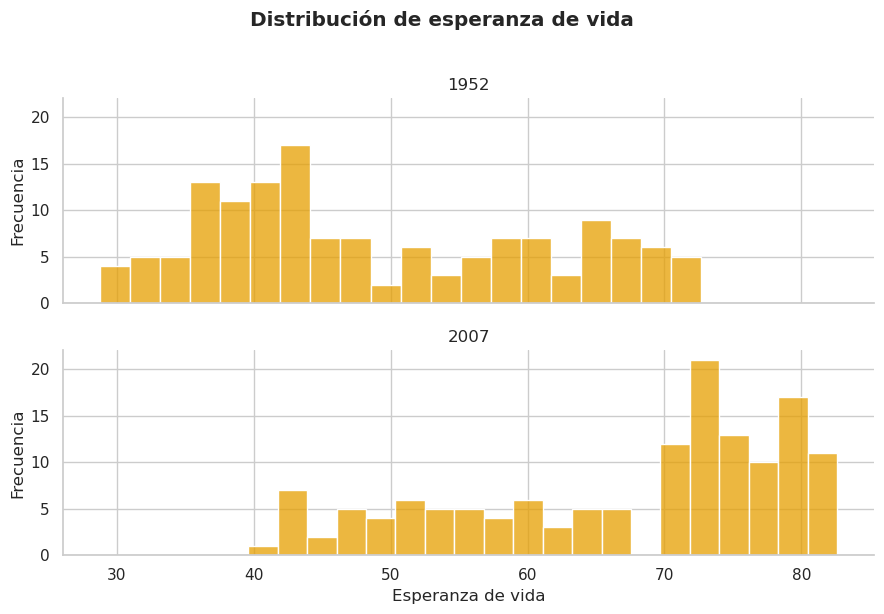

In [30]:
# Recrear: comparar 1952 vs 2007
comparison = pl.concat([
    df_1952.with_columns(pl.lit('1952').alias('year_str')),
    df_2007.with_columns(pl.lit('2007').alias('year_str'))
])

g = sns.FacetGrid(
    comparison.to_pandas(), 
    row='year_str', 
    height=3, 
    aspect=3,
    sharex=True, 
    sharey=True
)
g.map(sns.histplot, 'lifeExp', bins=20, color=COLORBLIND_PALETTE[1])
g.set_axis_labels('Esperanza de vida', 'Frecuencia')
g.set_titles(row_template='{row_name}')
g.figure.suptitle('Distribución de esperanza de vida', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

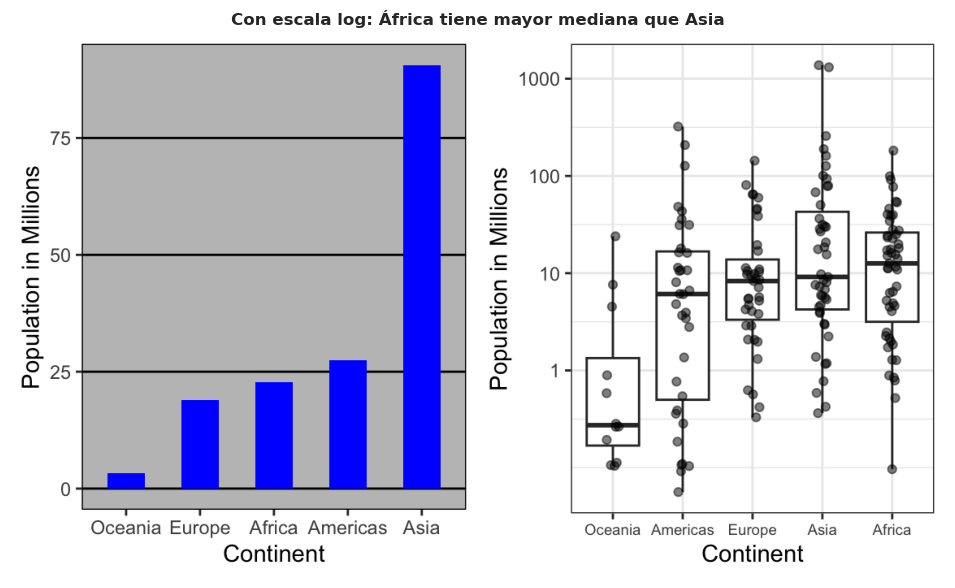

In [31]:
show_image('correct_transformation', 'Con escala log: África tiene mayor mediana que Asia')

/tmp/ipykernel_11540/2222345054.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


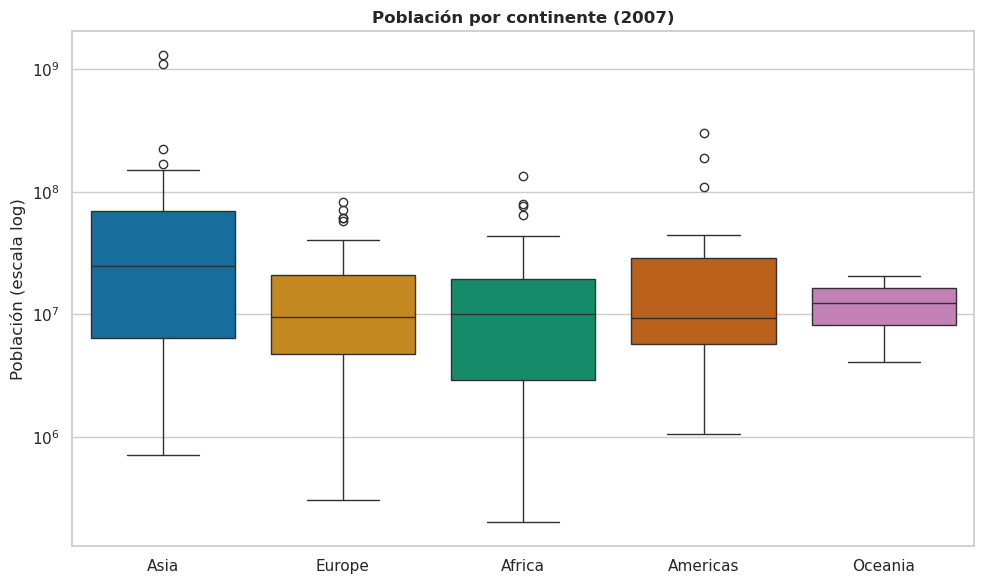

In [32]:
# Recrear: población por continente con escala log
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_2007.to_pandas(), 
    x='continent', 
    y='pop',
    palette='colorblind'
)

plt.yscale('log')
plt.xlabel('')
plt.ylabel('Población (escala log)')
plt.title('Población por continente (2007)', fontweight='bold')
plt.tight_layout()
plt.show()

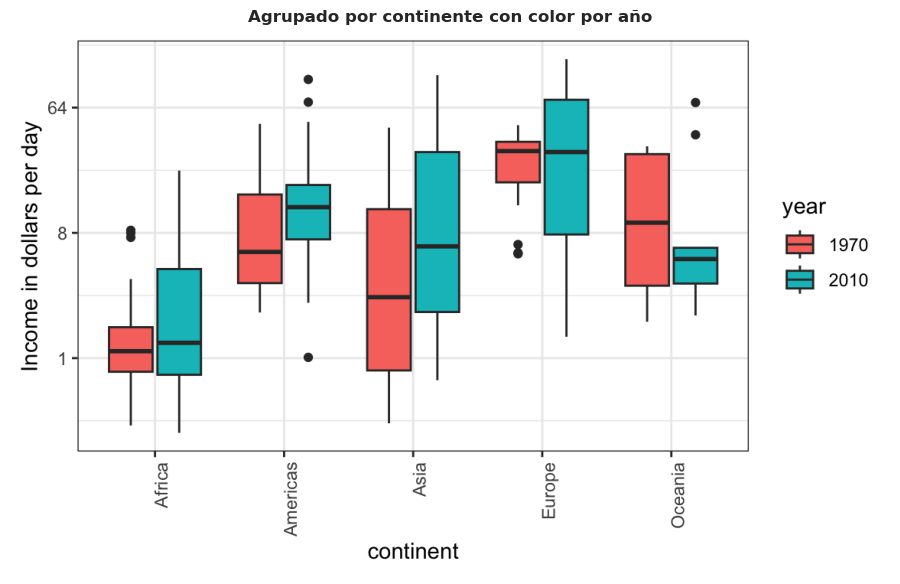

In [33]:
show_image('boxplot_adjacent_color', 'Agrupado por continente con color por año')

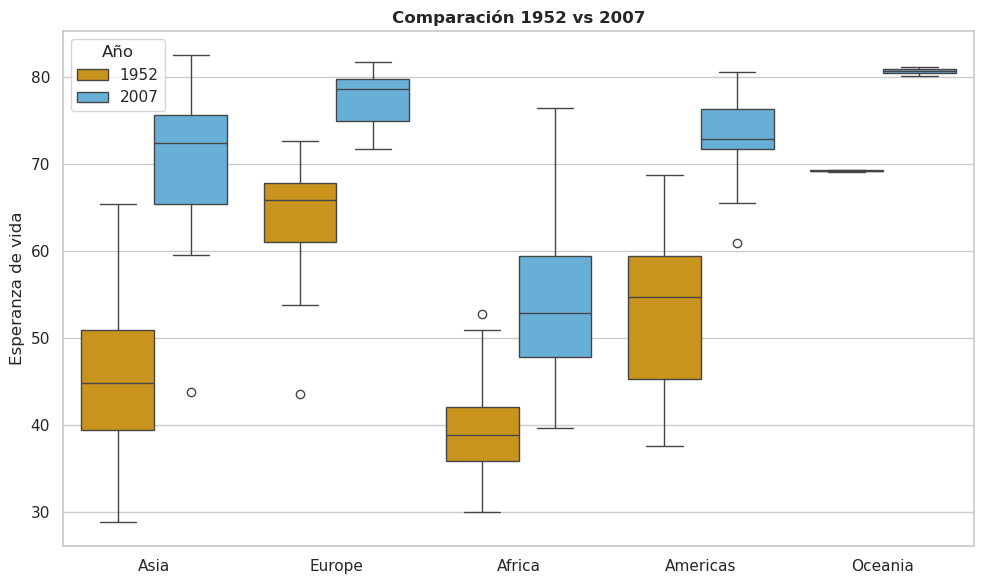

In [34]:
# Recrear: comparar 1952 vs 2007 por continente
comparison = df.filter(pl.col('year').is_in([1952, 2007]))

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=comparison.to_pandas(),
    x='continent',
    y='lifeExp',
    hue='year',
    palette=[COLORBLIND_PALETTE[1], COLORBLIND_PALETTE[2]]
)

plt.xlabel('')
plt.ylabel('Esperanza de vida')
plt.title('Comparación 1952 vs 2007', fontweight='bold')
plt.legend(title='Año')
plt.tight_layout()
plt.show()

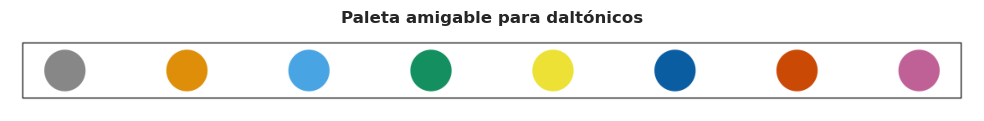

In [35]:
show_image('colorblind_palette', 'Paleta amigable para daltónicos')

In [36]:
print("Paleta para daltónicos:")
print(COLORBLIND_PALETTE)

Paleta amigable para daltónicos:
['#999999', '#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7']

En Seaborn usar: palette='colorblind'


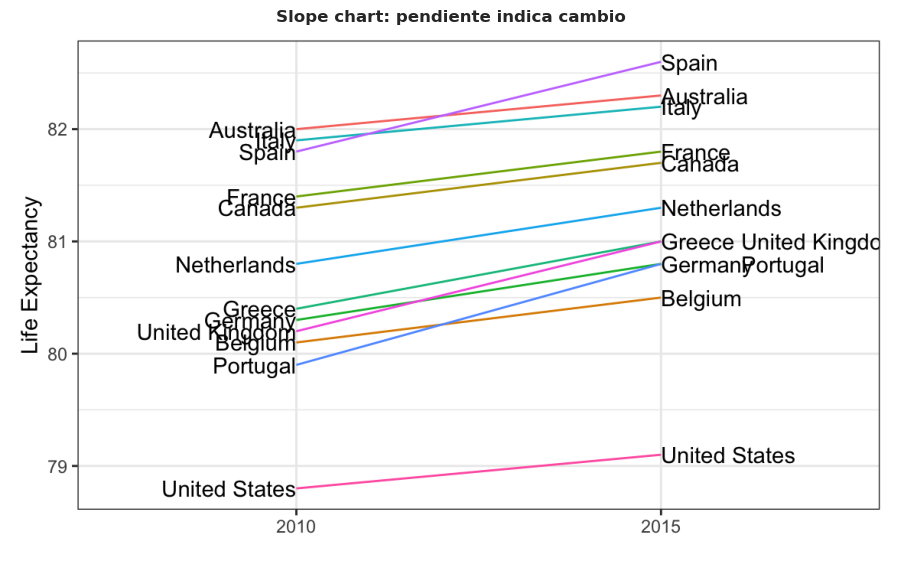

In [37]:
show_image('slope_chart', 'Slope chart: pendiente indica cambio')

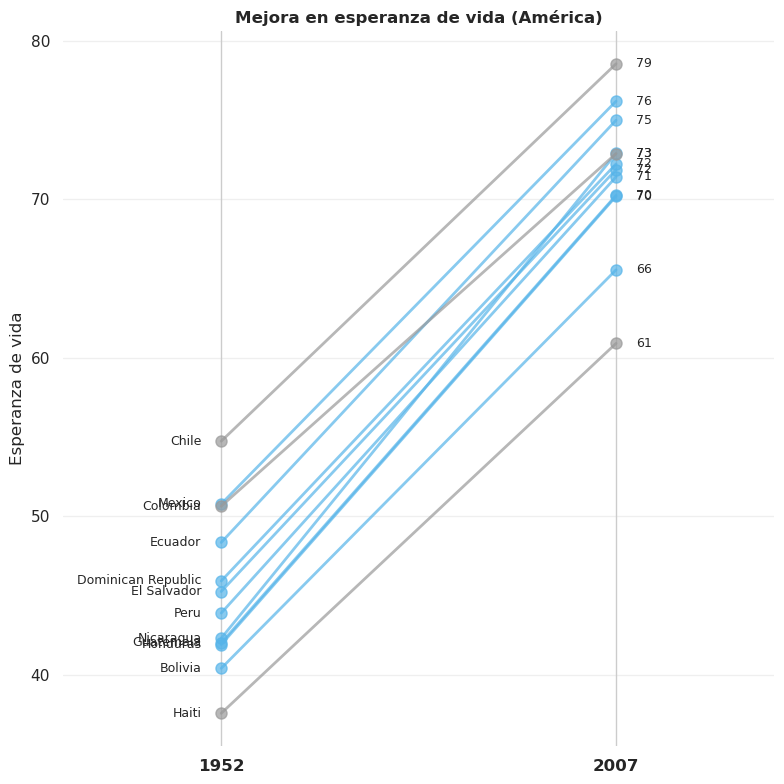

In [38]:
# Recrear slope chart
americas_wide = (
    df
    .filter(
        (pl.col('continent') == 'Americas') &
        (pl.col('year').is_in([1952, 2007]))
    )
    .pivot(on='year', index='country', values='lifeExp')
    .rename({'1952': 'y1952', '2007': 'y2007'})
    .with_columns((pl.col('y2007') - pl.col('y1952')).alias('change'))
    .sort('change', descending=True)
    .head(12)
)

fig, ax = plt.subplots(figsize=(8, 8))

for row in americas_wide.iter_rows(named=True):
    color = COLORBLIND_PALETTE[2] if row['change'] > 25 else COLORBLIND_PALETTE[0]
    ax.plot([0, 1], [row['y1952'], row['y2007']],
            marker='o', color=color, linewidth=2, alpha=0.7, markersize=8)
    ax.text(-0.05, row['y1952'], row['country'], ha='right', va='center', fontsize=9)
    ax.text(1.05, row['y2007'], f"{row['y2007']:.0f}", ha='left', va='center', fontsize=9)

ax.set_xlim(-0.4, 1.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(['1952', '2007'], fontsize=12, fontweight='bold')
ax.set_ylabel('Esperanza de vida')
ax.set_title('Mejora en esperanza de vida (América)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

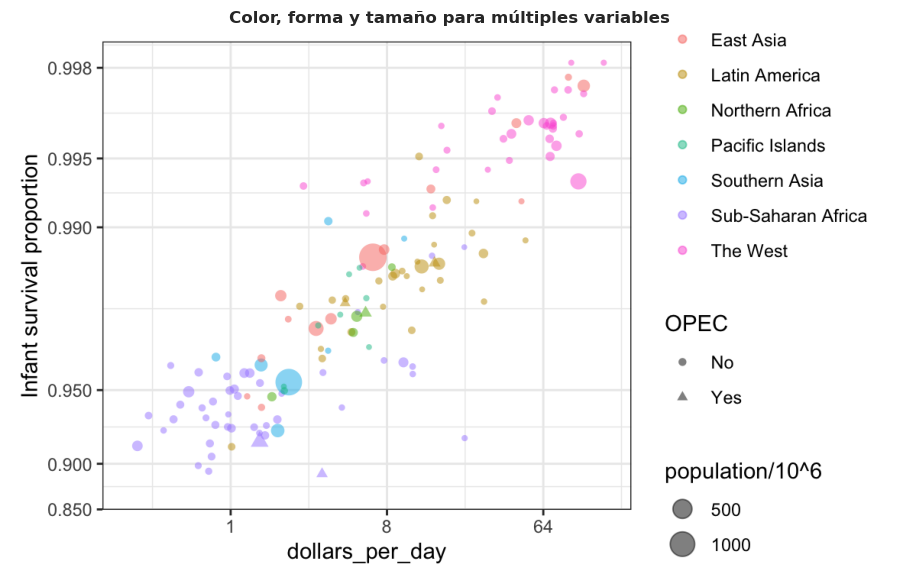

In [39]:
show_image('encoding_third_var', 'Color, forma y tamaño para múltiples variables')

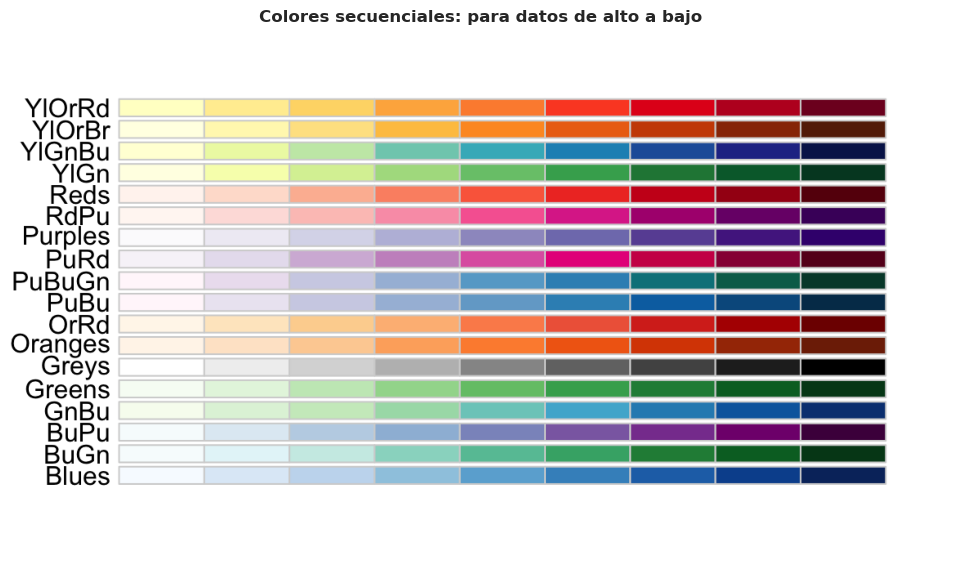

In [40]:
show_image('sequential_colors', 'Colores secuenciales: para datos de alto a bajo')

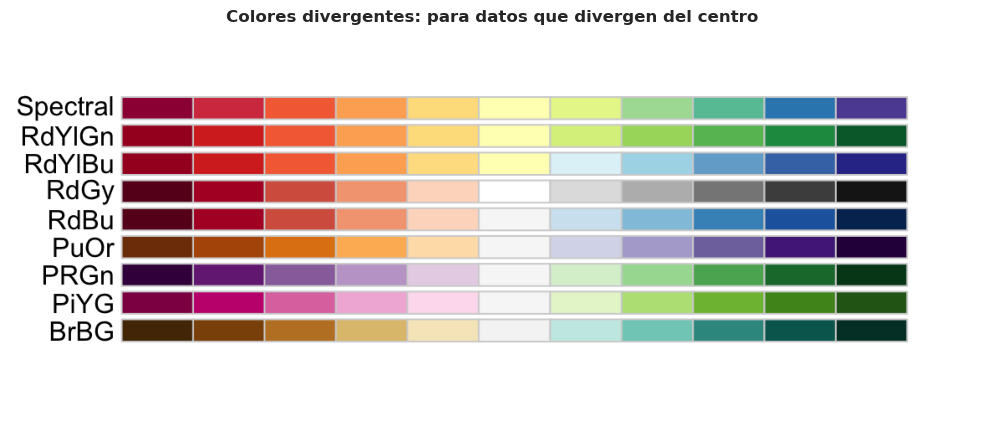

In [41]:
show_image('diverging_colors', 'Colores divergentes: para datos que divergen del centro')

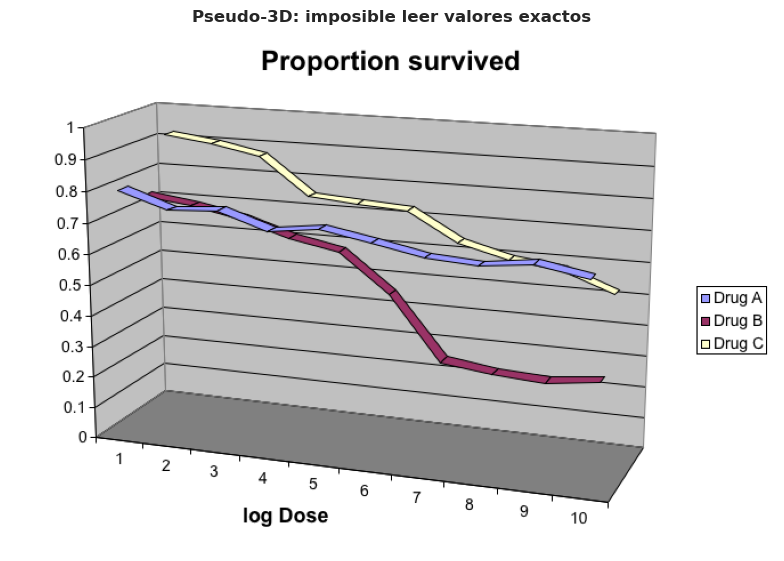

In [42]:
show_image('pseudo_3d', 'Pseudo-3D: imposible leer valores exactos', figsize=(8, 6))

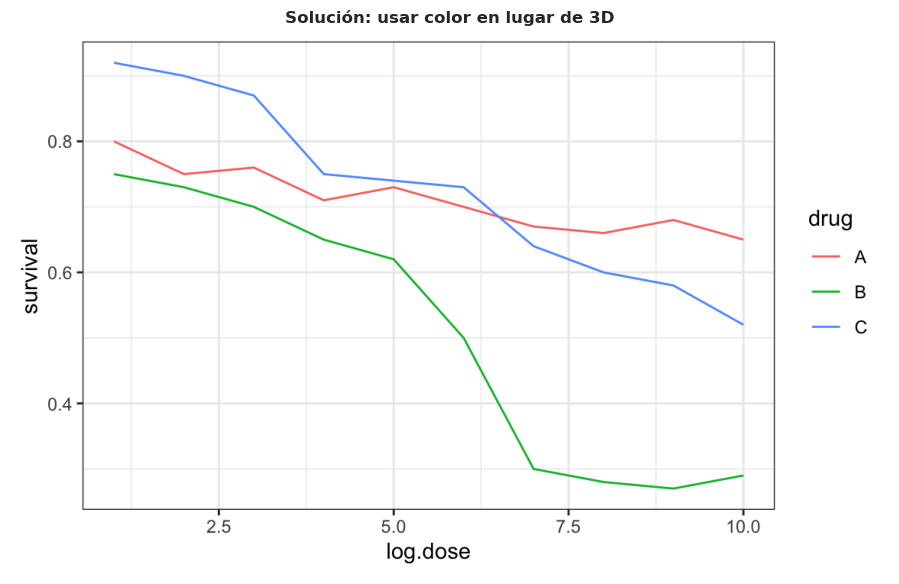

In [43]:
show_image('colors_for_lines', 'Solución: usar color en lugar de 3D')

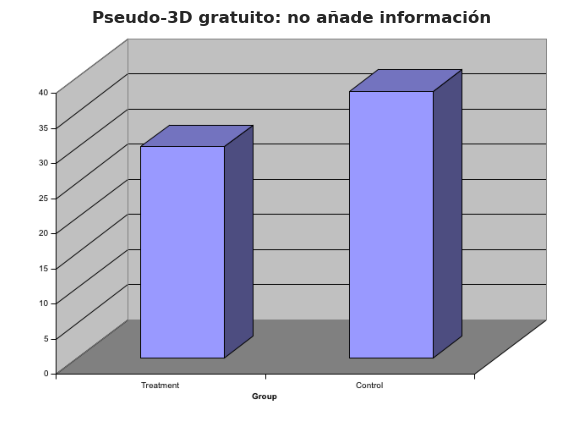

In [44]:
show_image('pseudo_3d_gratuitous_1', 'Pseudo-3D gratuito: no añade información', figsize=(6, 5))

In [46]:
example = (
    df_2007
    .filter(pl.col('continent') == 'Americas')
    .select(['country', 'lifeExp', 'gdpPercap'])
    .head(5)
)

print("Demasiados dígitos:")
print(example)

print("\nDígitos apropiados:")
print(
    example
    .with_columns([
        pl.col('lifeExp').round(1),
        pl.col('gdpPercap').round(0).cast(pl.Int64)
    ])
)

Demasiados dígitos:
shape: (5, 3)
┌───────────┬─────────┬─────────────┐
│ country   ┆ lifeExp ┆ gdpPercap   │
│ ---       ┆ ---     ┆ ---         │
│ str       ┆ f64     ┆ f64         │
╞═══════════╪═════════╪═════════════╡
│ Argentina ┆ 75.32   ┆ 12779.37964 │
│ Bolivia   ┆ 65.554  ┆ 3822.137084 │
│ Brazil    ┆ 72.39   ┆ 9065.800825 │
│ Canada    ┆ 80.653  ┆ 36319.23501 │
│ Chile     ┆ 78.553  ┆ 13171.63885 │
└───────────┴─────────┴─────────────┘

Dígitos apropiados:
shape: (5, 3)
┌───────────┬─────────┬───────────┐
│ country   ┆ lifeExp ┆ gdpPercap │
│ ---       ┆ ---     ┆ ---       │
│ str       ┆ f64     ┆ i64       │
╞═══════════╪═════════╪═══════════╡
│ Argentina ┆ 75.3    ┆ 12779     │
│ Bolivia   ┆ 65.6    ┆ 3822      │
│ Brazil    ┆ 72.4    ┆ 9066      │
│ Canada    ┆ 80.7    ┆ 36319     │
│ Chile     ┆ 78.6    ┆ 13172     │
└───────────┴─────────┴───────────┘


In [47]:
## Referencias

- Irizarry, R. (2024). *Introduction to Data Science*, Capítulo 9.  
  https://rafalab.dfci.harvard.edu/dsbook-part-1/dataviz/dataviz-principles.html
- Gapminder: https://www.gapminder.org/

SyntaxError: invalid syntax (2640225826.py, line 3)